In [1]:
from google.colab import files
import zipfile
import os
import pandas as pd

# Upload the ZIP file
uploaded = files.upload()

# Get the uploaded ZIP filename
zip_file = next(iter(uploaded))

# Extract the ZIP
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    df = pd.read_csv("/content/dataset/train.csv")

print("Files extracted:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip
Files extracted:
/content/dataset/sample_submission.csv
/content/dataset/test.csv
/content/dataset/train.csv
/content/dataset/data_description.txt


In [2]:
df.head(100
        )

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,60,RL,NaN,9765,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,Shed,480,4,2009,WD,Normal,185000
96,97,20,RL,78.0,10264,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2006,WD,Normal,214000
97,98,20,RL,73.0,10921,Pave,NaN,Reg,HLS,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,94750
98,99,30,RL,85.0,10625,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,400,5,2010,COD,Abnorml,83000


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit


In [4]:
from sklearn.model_selection import train_test_split
X=df.drop("SalePrice",axis=1)
Y=df["SalePrice"]
X_train, X_valid, y_train, y_valid=train_test_split (
    X,
  Y,
                                                 test_size=0.2,
                                                 random_state=42)
print(X_train.shape)
print(X_valid.shape)

(1168, 80)
(292, 80)


In [5]:
housing=X_train.copy()
housing["SalePrice"] = y_train

In [6]:
housing.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


In [7]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

In [8]:
housing.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,...,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493,181441.541952
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,...,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639,77263.583862
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,130000.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,165000.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214925.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,745000.000000


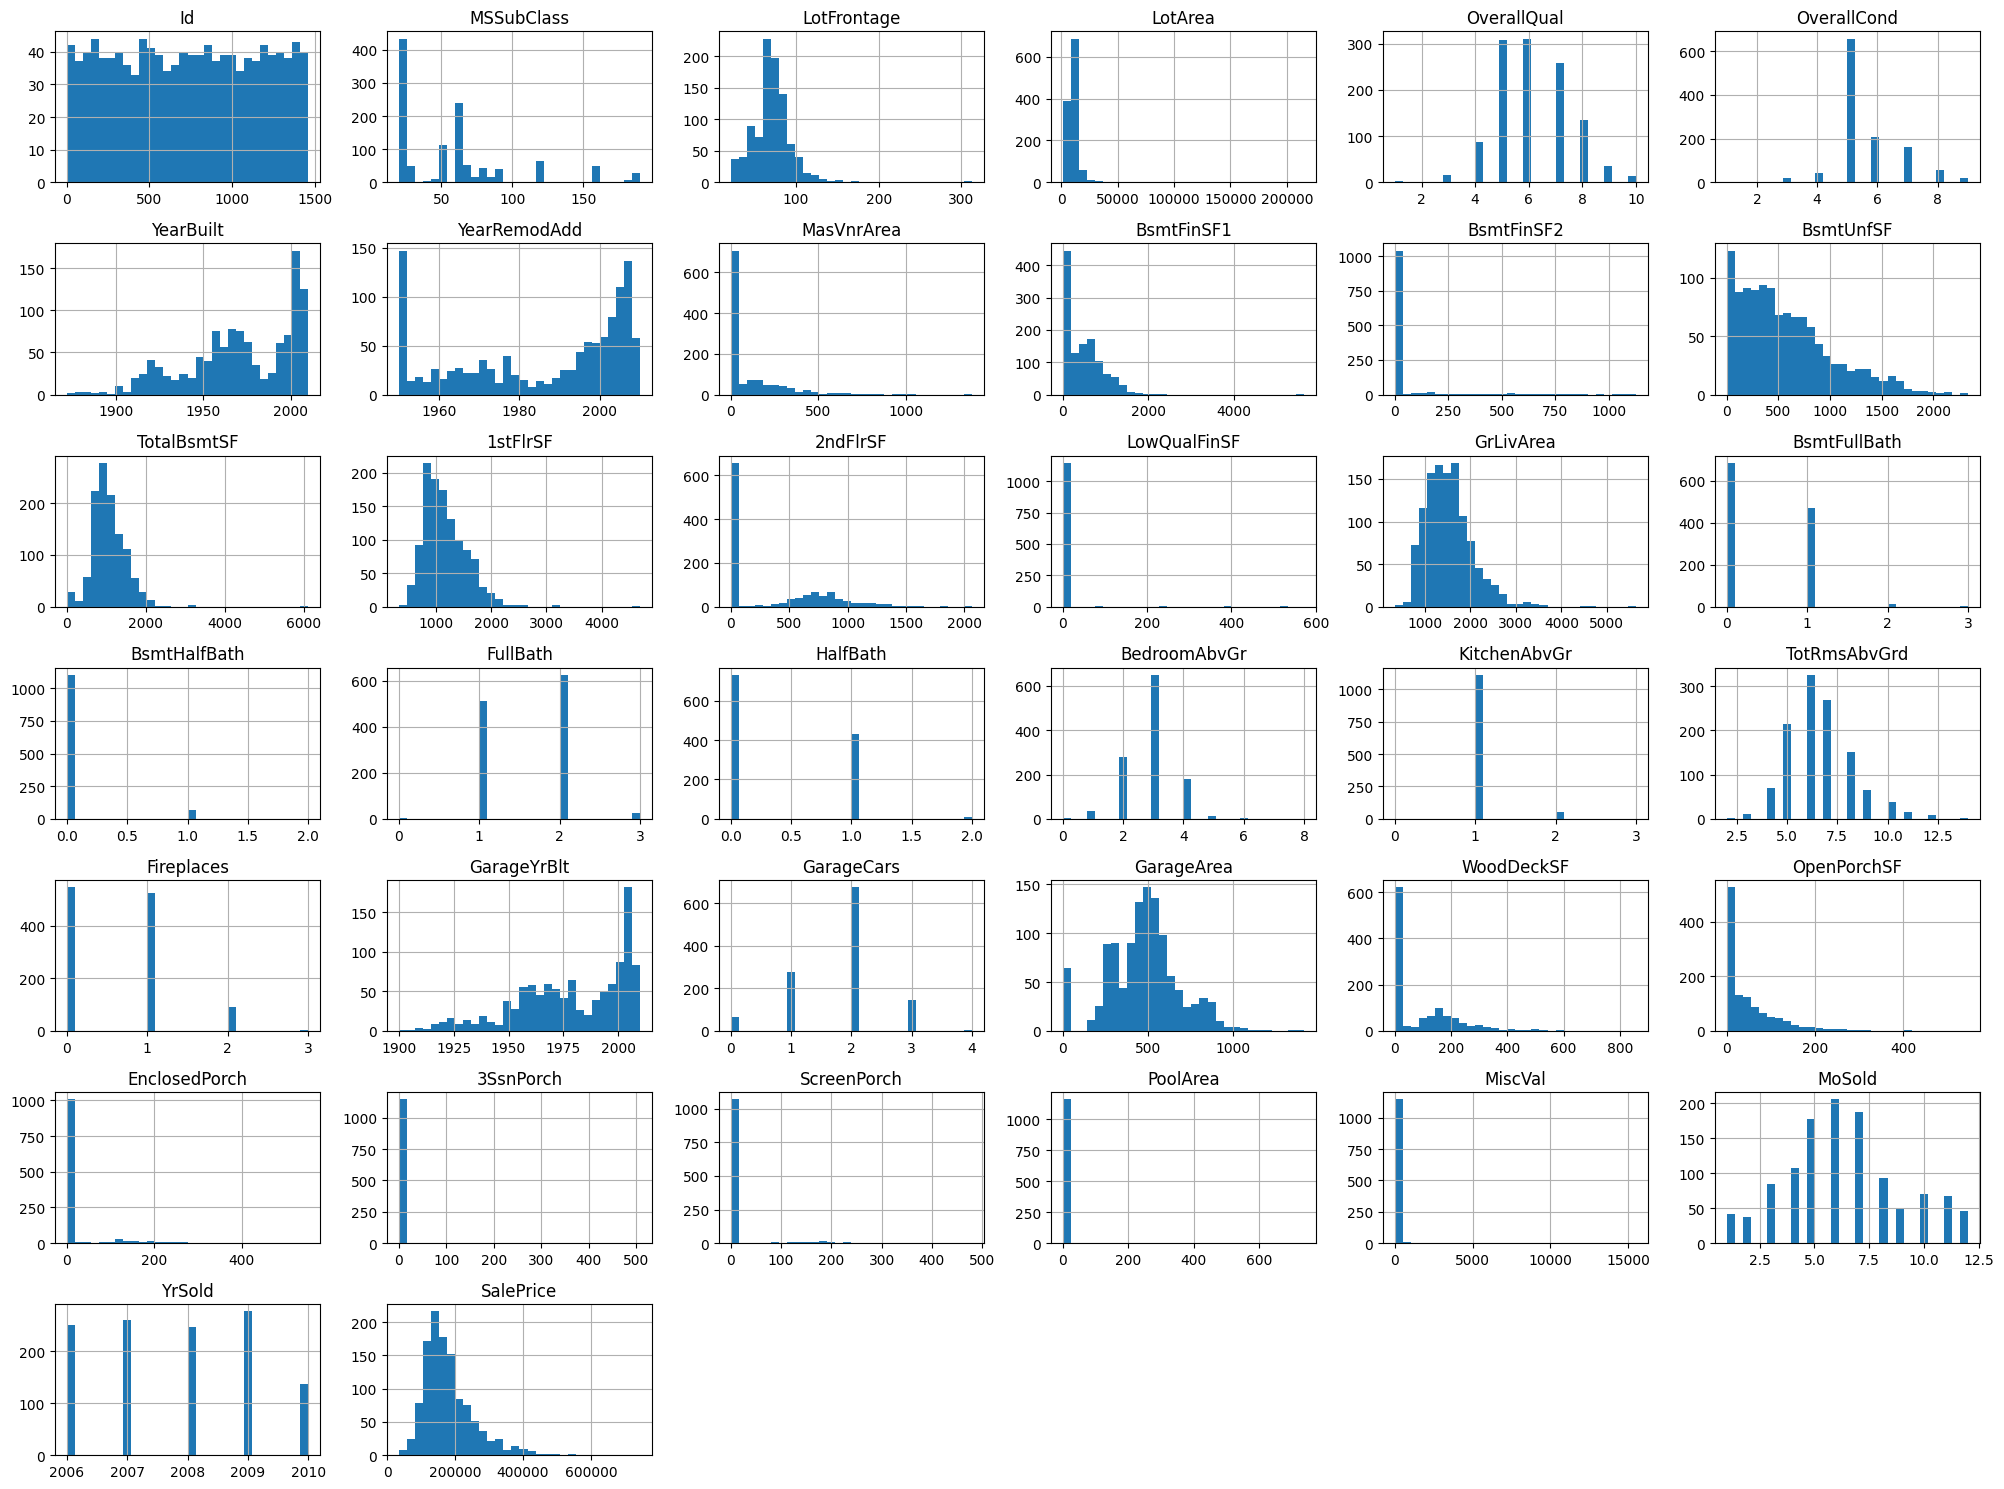

In [9]:
import matplotlib.pyplot as plt
housing.hist(figsize=(20,15),bins=30)
plt.tight_layout()
plt.show()

In [10]:
missing = housing.isnull().sum().sort_values(ascending=False)
missing[missing>0]

,0
PoolQC,1162
MiscFeature,1122
Alley,1094
Fence,935
MasVnrType,683
FireplaceQu,547
LotFrontage,217
GarageQual,64
GarageFinish,64
GarageType,64


In [11]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.785555
GrLivArea,0.695652
GarageCars,0.640991
GarageArea,0.624139
TotalBsmtSF,0.597766
1stFlrSF,0.587883
FullBath,0.552546
TotRmsAbvGrd,0.520388
YearBuilt,0.516501


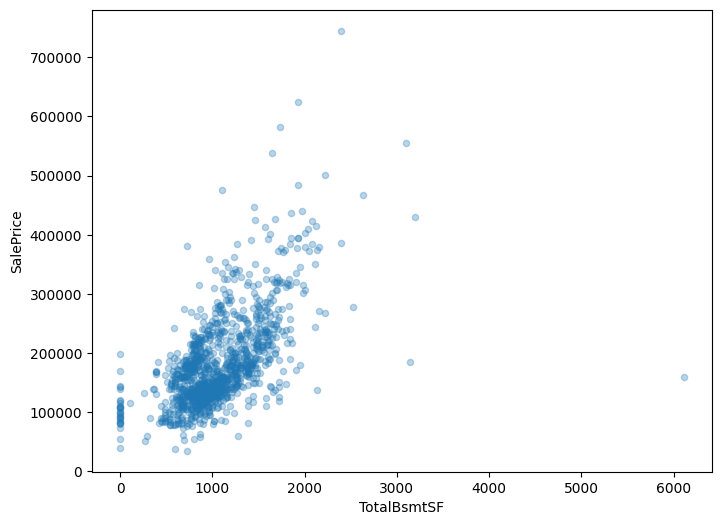

In [12]:

import matplotlib.pyplot as plt
housing.plot(
    kind="scatter",
    x="TotalBsmtSF",
    y="SalePrice",
    alpha=0.3,
    figsize=(8,6)

)
plt.show()

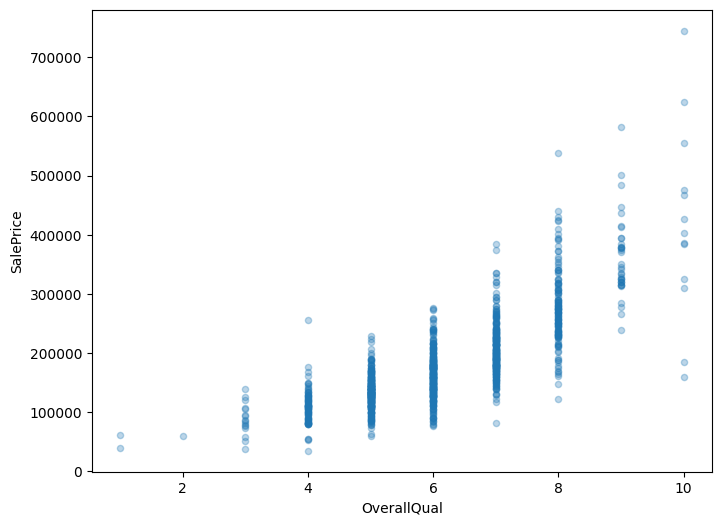

In [13]:
import matplotlib.pyplot as plt
housing.plot(
    kind="scatter",
    x="OverallQual",
    y="SalePrice",
    alpha=0.3,
    figsize=(8,6)

)
plt.show()

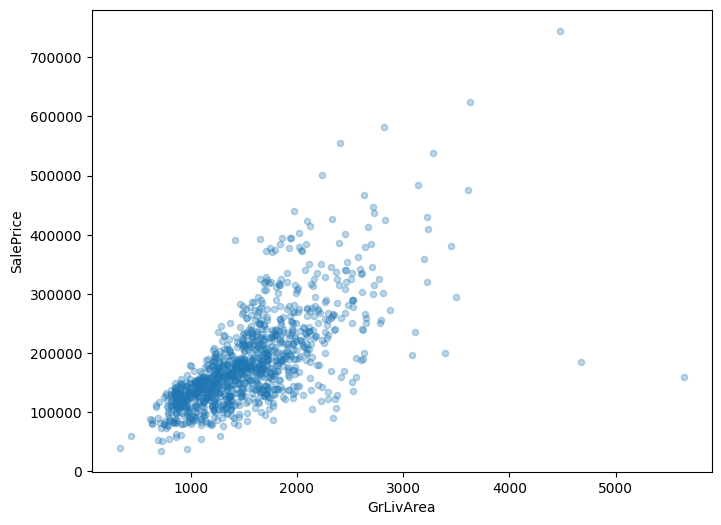

In [14]:
import matplotlib.pyplot as plt
housing.plot(
    kind="scatter",
    x="GrLivArea",
    y="SalePrice",
    alpha=0.3,
    figsize=(8,6)

)
plt.show()

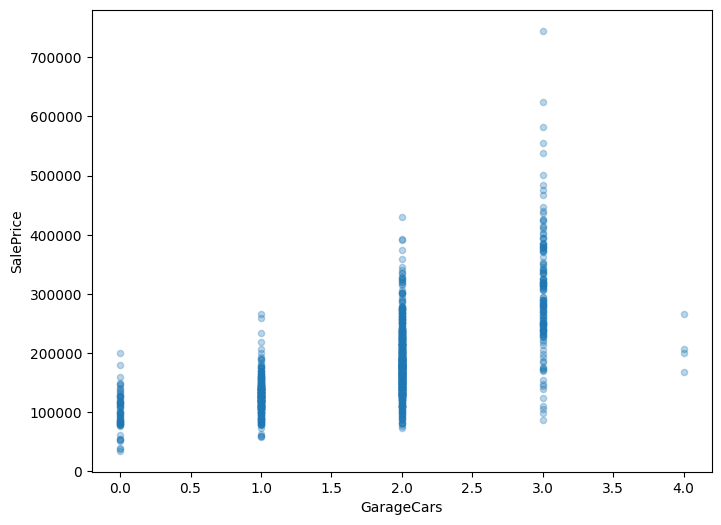

In [15]:
import matplotlib.pyplot as plt
housing.plot(
    kind="scatter",
    y="SalePrice",
    x="GarageCars",
    alpha=0.3,
    figsize=(8,6)

)
plt.show()

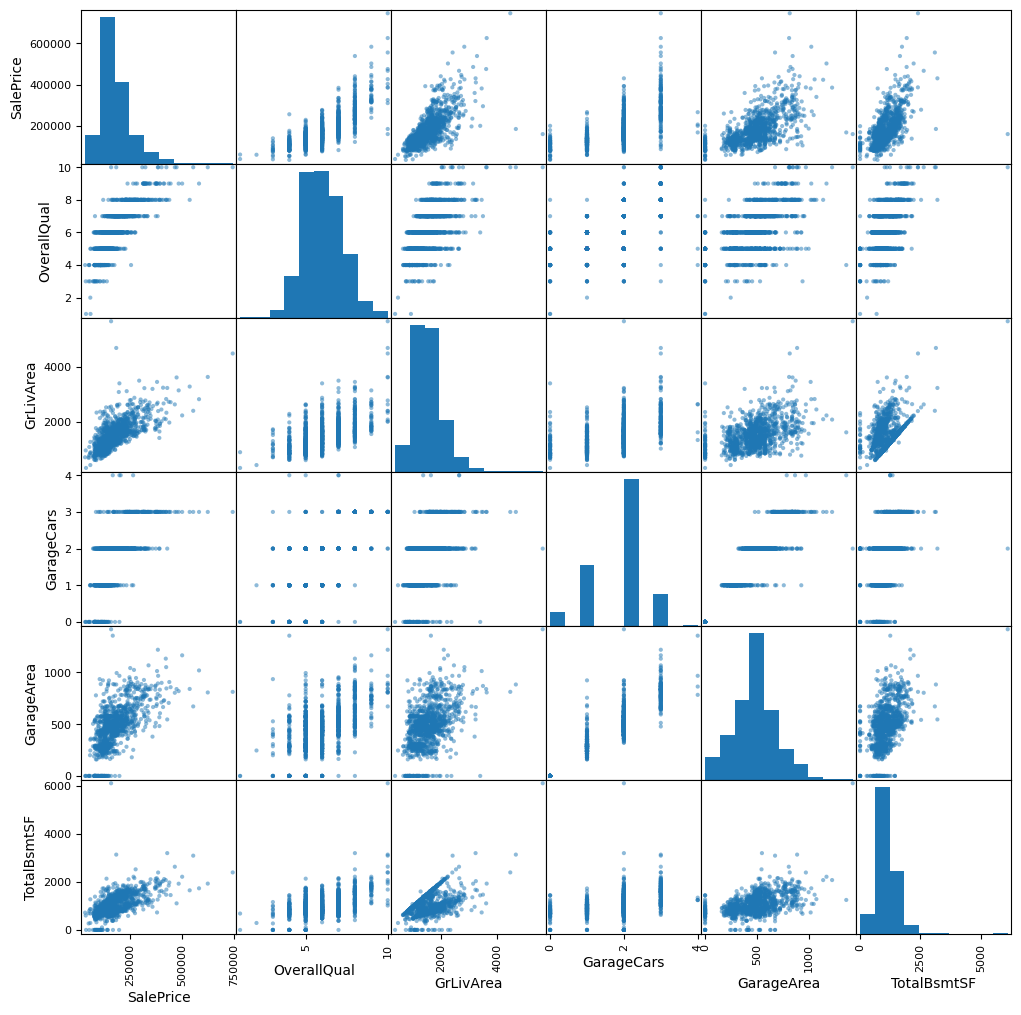

In [16]:
from pandas.plotting import scatter_matrix
attributes = [
   "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF"
]
scatter_matrix(housing[attributes],figsize=(12,12))
plt.show()

In [18]:
missing = housing.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing


,0
PoolQC,1162
MiscFeature,1122
Alley,1094
Fence,935
MasVnrType,683
FireplaceQu,547
LotFrontage,217
GarageType,64
GarageYrBlt,64
GarageFinish,64


In [25]:
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns
print("Numerical FEatures ",numerical_features)
print("categorical Features",categorical_features)


Numerical FEatures  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')
categorical Features Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFi

In [26]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [27]:
num_imputer.fit(X_train[numerical_features])
cat_imputer.fit(X_train[categorical_features])

SimpleImputer(strategy='most_frequent')

In [29]:
X_train_num = num_imputer.transform(X_train[numerical_features])
X_train_cat = cat_imputer.transform(X_train[categorical_features])

In [32]:
print(X_train_num.shape)
print(X_train_cat.shape)
print(type(X_train_num))
print(type(X_train_cat))

(1168, 37)
(1168, 43)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [33]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])

In [34]:
print(X_train_cat_encoded.shape)

(1168, 265)


In [35]:
import numpy as np
X_train_prepared = np.hstack((X_train_num,X_train_cat_encoded))
print(X_train_prepared.shape)

(1168, 302)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , StandardScaler

In [45]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num",num_pipeline, numerical_features),
    ("cat",cat_pipeline, categorical_features)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_preapred = preprocessor.transform(X_valid)
print(X_train_prepared.shape)
encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]

print(len(encoder.get_feature_names_out()))

(1168, 286)
249


In [44]:
print(len(numerical_features))

37


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

In [48]:
linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [49]:
y_pred = linear_model.predict(X_valid)

In [50]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse=np.sqrt(mean_squared_error(y_valid,y_pred))
print("Validation Rmse : ", rmse)



Validation Rmse :  29477.00482523972


In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

train_pred = linear_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train,train_pred))
print("Training Rmse : ",train_rmse)
print("Validation Rmse : ", rmse)

Training Rmse :  19529.045410344304
Validation Rmse :  29477.00482523972


In [52]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeRegressor(random_state = 42))
])
decision_tree.fit(X_train,y_train)

train_pred = decision_tree.predict(X_train)
valid_pred = decision_tree.predict(X_valid)

train_rmse = np.sqrt(mean_squared_error(y_train,train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_valid,valid_pred))

print("Decision Tree")
print("Training RMSE : ",train_rmse)
print("Validation RMSE : ", valid_rmse)

Decision Tree
Training RMSE :  0.0
Validation RMSE :  41853.012719622755


In [54]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])


random_forest.fit(X_train, y_train)

train_pred = random_forest.predict(X_train)
valid_pred = random_forest.predict(X_valid)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))

print("Random Forest")
print("Training RMSE :", train_rmse)
print("Validation RMSE :", valid_rmse)

Random Forest
Training RMSE : 11334.650574483683
Validation RMSE : 28527.52033809099


In [55]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boost = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Train
gradient_boost.fit(X_train, y_train)

# Predictions
train_pred = gradient_boost.predict(X_train)
valid_pred = gradient_boost.predict(X_valid)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))

print("Gradient Boosting")
print("Training RMSE :", train_rmse)
print("Validation RMSE :", valid_rmse)

Gradient Boosting
Training RMSE : 13355.067570217168
Validation RMSE : 26135.73811989404


In [61]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from scipy.stats import randint, uniform
import numpy as np

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 6),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__subsample": uniform(0.7, 0.3)
}


random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)


random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)


best_model = random_search.best_estimator_


pred = best_model.predict(X_valid)


rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("Optimized Validation RMSE:", rmse)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'model__learning_rate': np.float64(0.1827708763949686), 'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 9, 'model__n_estimators': 487, 'model__subsample': np.float64(0.7935133228268232)}
Optimized Validation RMSE: 24817.862243859297


In [62]:
train_pred = best_model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

print("Training RMSE:", train_rmse)
print("Validation RMSE:", rmse)


Training RMSE: 100.57590975697224
Validation RMSE: 24817.862243859297


In [63]:
train_df = pd.read_csv("/content/dataset/train.csv")
test_df = pd.read_csv("/content/dataset/test.csv")

X_full = train_df.drop("SalePrice", axis=1)
y_full = train_df["SalePrice"]

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        learning_rate=0.1827708763949686,
        max_depth=5,
        min_samples_leaf=2,
        min_samples_split=9,
        n_estimators=487,
        subsample=0.7935133228268232,
        random_state=42
    ))
])

final_model.fit(X_full, y_full)


test_predictions = final_model.predict(test_df)

In [64]:
import joblib

joblib.dump(best_model, "gradient_boosting_model.pkl")

print("Model saved successfully!")

import pickle

with open("gradient_boosting_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

    from google.colab import files

files.download("gradient_boosting_model.pkl")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
test_predictions = final_model.predict(test_df)

In [67]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

from google.colab import files

files.download("submission.csv")

submission.csv created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>